<a href="https://colab.research.google.com/github/rocioivonneperezgonzalez-ship-it/Telecom-X-Parte-2-Predicci-n-de-Cancelaci-n-Churn-/blob/main/Telecom_X_%E2%80%93_Parte_2_Prediccion_de_Cancelacion_(Churn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style = " color:red" Telecom X – Parte 2: Predicción de Cancelación (Churn)</h1>

# <font color='dark'>**Challenge Telecom X- Análisis de evasión de clientes – Parte 2**</h1>
  



📣 Historia del Desafío

¡Felicidades! 🎉 Has sido promovido después de tu excelente desempeño en el análisis exploratorio de la cancelación de clientes en Telecom X. Tu dedicación, claridad al comunicar los datos y visión estratégica marcaron la diferencia.

Ahora, ¡has sido invitado oficialmente a formar parte del equipo de Machine Learning de la empresa!

🎯 Misión

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.


🧠 Objetivos del Desafío


  * Preparar los datos para el modelado (tratamiento, codificación, normalización).

  * Realizar análisis de correlación y selección de variables.

  * Entrenar dos o más modelos de clasificación.

  * Evaluar el rendimiento de los modelos con métricas.

  * Interpretar los resultados, incluyendo la importancia de las variables.

  * Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

🧰 Lo que vas a practicar

✅ Preprocesamiento de datos para Machine Learning

✅ Construcción y evaluación de modelos predictivos

✅ Interpretación de resultados y entrega de insights

✅ Comunicación técnica con enfoque estratégico

# <font color='blue'>***1. Extracción de datos***</h1>


Cargar el archivo CSV que contiene los datos tratados anteriormente.
Utilizando el mismo archivo que limpiamos y organizamos en la Parte 1 del desafio, el cuela debe obtener solo las columnsas relevantes, ya con los datos corregidos

In [1]:
import pandas as pd

url = 'https://drive.google.com/uc?id=1hQZIufjMa_n3cXApTcFQPx2mMBQ8J1Qc'
datos = pd.read_csv(url)

datos.head(10)


,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
5,0013-MHZWF,No,Female,No,No,Yes,9,Yes,No,DSL,...,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),2.31,69.40,571.45
6,0013-SMEOE,No,Female,Yes,Yes,No,71,Yes,No,Fiber optic,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),3.66,109.70,7904.25
7,0014-BMAQU,No,Male,No,Yes,No,63,Yes,Yes,Fiber optic,...,No,Yes,No,No,Two year,Yes,Credit card (automatic),2.82,84.65,5377.80
8,0015-UOCOJ,No,Female,Yes,No,No,7,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,1.61,48.20,340.35
9,0016-QLJIS,No,Female,No,Yes,Yes,65,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,Two year,Yes,Mailed check,3.02,90.45,5957.90


In [2]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [3]:
datos.describe()

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,2.158675,64.761692,2279.734304
std,24.559481,1.003088,30.090047,2266.794470
min,0.000000,0.610000,18.250000,0.000000
25%,9.000000,1.180000,35.500000,398.550000
50%,29.000000,2.340000,70.350000,1394.550000
75%,55.000000,2.990000,89.850000,3786.600000
max,72.000000,3.960000,118.750000,8684.800000


In [4]:
datos.isnull().sum()

,0
CustomerID,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


# <font color='blue'>***2. Preprocesamiento***</h1>


**2.1 Eliminación de columnas**

Eliminemos columnas que no aportan valor al analisis o a los modelos predictivos, como identificadores unicos ( por ejemplo el ID del cliente). Estas columnas nos ayudan en la predicion de la cancelación y puede incluso perjudicar el desempeño de los modelos

In [5]:
datos.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [6]:
datos = datos.drop(columns=['CustomerID'])

In [7]:
datos.columns

Index(['Churn', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'ChargesDaily', 'ChargesMonthly', 'ChargesTotal'],
      dtype='object')

In [8]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    datos[col] = datos[col].replace({'No internet service': 'No'})

Verificación nuevamente de datos nulos

In [9]:
datos.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# <font color='blue'>***3. Analisi Exploratorio (EDA)***</h1>


## **3.1 Análisis de correlación**

Visualiza la matriz de correlación para identificar relaciones entre varias variables numericas. Prestando una mayor  atencion a las variables que muetrean una mayor corelación con la caqncelación, ya que estasn pueden ser fuerte candidatos para el modelos predfictivo

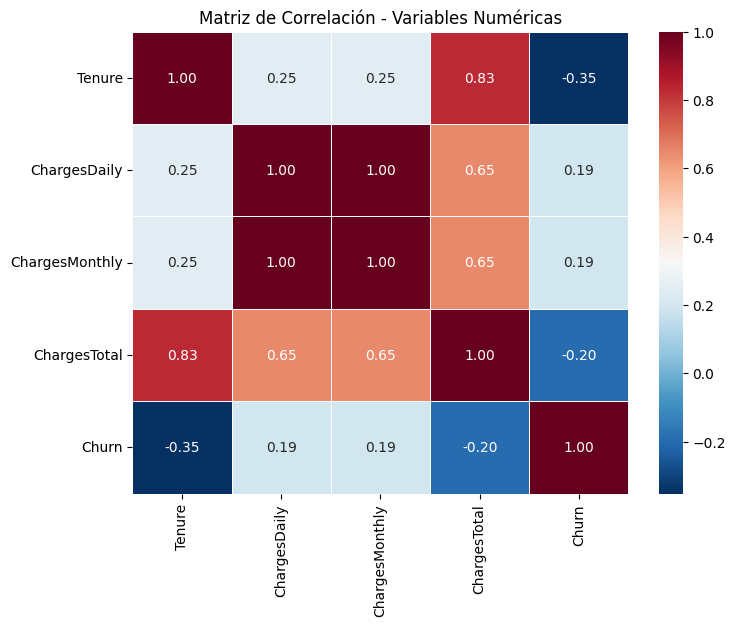

In [10]:
# Seleccionar solo variables numéricas
datos_numericos = datos.select_dtypes(include=['int64', 'float64'])

# Convertir Churn a numérico SOLO para correlación
datos_numericos["Churn"] = datos["Churn"].map({"Yes": 1, "No": 0})

matriz_corr = datos_numericos.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap="RdBu_r",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlación - Variables Numéricas")

plt.show()

In [11]:
plt.savefig("Matriz de Correlación - Variables Numéricas.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

**🔎 1️⃣Variables con mayor correlación con Churn**

**🔵 Tenure vs Churn → -0.35**

*Existe una correlación negativa moderada.*

👉 Indicando a mayor tiempo de permanencia del cliente (Tenure), menor probabilidad de cancelación.

📌 Interpretación: Los clientes nuevos tienden a cancelar más que los clientes antiguos. Esta variable es un fuerte candidato predictivo para el modelo.

**🔵 ChargesTotal vs Churn → -0.20**

*Correlación negativa débil.*

Los clientes con mayor gasto acumulado tienden ligeramente a cancelar menos.

📌 Sin embargo, esta relación es más débil que la de Tenure.

**🔵 ChargesDaily y ChargesMonthly vs Churn → 0.19**

*Correlación positiva débil.*

Clientes con cargos mensuales más altos tienen ligeramente mayor probabilidad de cancelar.

📌 Aunque la relación no es fuerte, puede aportar información combinada en el modelo.

**⚠ 2️⃣ Alta correlación entre variables predictoras**

**🔴 ChargesDaily vs ChargesMonthly → 1.00**

Correlación perfecta.

Esto indica que ambas variables contienen exactamente la misma información.

📌 Esto genera multicolinealidad, lo cual puede afectar modelos como:

* Regresión Logística

* SVM

👉 Dado a esto solo se concervara uno de los dos

**🔴 Tenure vs ChargesTotal → 0.83**

Correlación alta positiva.

Tiene sentido porque el gasto total depende del tiempo de permanencia.

📌 No es necesariamente un problema, pero es importante tenerlo en cuenta.

👉 Dado a ello tambien se toma a consideracion para eliminación

**🧠 Interpretación estratégica**

El comportamiento sugiere que:

* Los clientes cancelan principalmente en etapas tempranas.

* Los clientes con cargos mensuales más altos tienen ligeramente mayor riesgo.

* La permanencia es el factor más determinante.

## **3.2 Selección de variables (basado en correlación)**

In [12]:
datos = datos.drop(columns=['ChargesDaily', 'ChargesTotal'])
datos.columns

Index(['Churn', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'ChargesMonthly'],
      dtype='object')

## ***3.3 Analisis de Churn por categorias (variables categoricas)***

In [13]:
# Seleción de variables catgoricas

categorical_cols = datos.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")

Tabla de proporción por categoria

In [14]:
for col in categorical_cols:
    print(f"\n📌 Analisis de variable: {col}")
    display(pd.crosstab(datos[col], datos["Churn"], normalize="index") * 100)


📌 Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌 Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



📌 Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌 Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌 Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## **3.4 Anlisís Dirigido**

Analisamos como variables especificas se relacionan, tales como:

* Tiempon de contrato x Cancelacion
* Gato total x Cancelación

Sin embargo, dado a que `ChargesTotal` fue eliminado anteriomento, descartamos su análisis

***📌 1️⃣ Tiempo de contrato × Cancelación***

/tmp/ipython-input-192802763.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


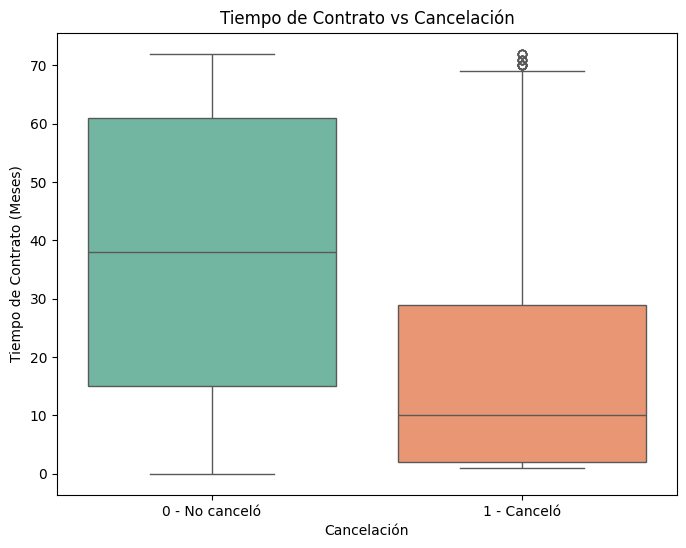

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(
    x="Churn",
    y="Tenure",
    data=datos,
    palette="Set2"
)

plt.title("Tiempo de Contrato vs Cancelación")
plt.xlabel("Cancelación")
plt.xticks([0, 1], ['0 - No canceló', '1 - Canceló'])
plt.ylabel("Tiempo de Contrato (Meses)")
plt.show()

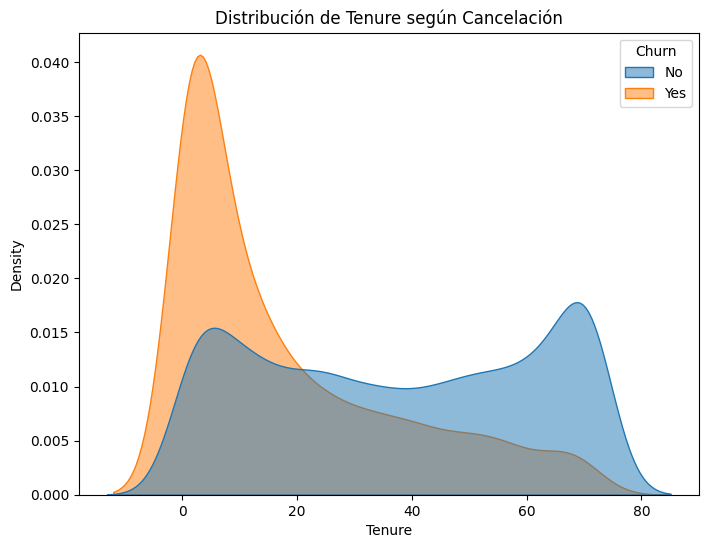

In [17]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=datos,
    x="Tenure",
    hue="Churn",
    fill=True,
    common_norm=False,
    alpha=0.5
)

plt.title("Distribución de Tenure según Cancelación")
plt.show()

# <font color='blue'>***4. Tranformación de los datos***</h1>

##**4.1 Separando las variables explicativas y variable objetivo**

In [19]:
X = datos.drop('Churn', axis=1)
y = datos['Churn']

In [20]:
X

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,Male,No,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,Male,No,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


In [21]:
y

,Churn
0,No
1,No
2,Yes
3,Yes
4,Yes
...,...
7038,No
7039,Yes
7040,No
7041,No


## **4.2 Separación en Conjunto de Entrenamiento y Prueba**

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## **4.3 Tranformando la variable Explicativas**

***Idenficando variables***

In [23]:
col_categoricas = X_train.select_dtypes(include='object').columns
col_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

***Creación del Preprocesador***

In [24]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

preprocesador = ColumnTransformer (
    transformers =[
        ('num', MinMaxScaler(), col_numericas),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), col_categoricas)
    ]
)


## **4.4 Tranformando la variable respuesta**

In [25]:
from sklearn.preprocessing import LabelEncoder

In [26]:
label_encoder = LabelEncoder()

In [27]:
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.fit_transform(y_test)

In [28]:
y_train

array([0, 1, 1, ..., 0, 0, 0])

In [29]:
y_test

array([1, 0, 1, ..., 0, 0, 0])

In [30]:
label_encoder.classes_

array(['No', 'Yes'], dtype=object)

## **4.5 Verificación de la Proporción de Cancelaación (Churn)**

Calcular la proporcion de clientes que cancelaron en relacipon con los que permanecen activos

Evaluando si existe un desvalance entre las clases, ya que esto pude impactar en los modelos predictivos y en el analisis de resultados

Para ello usamos el metodo `values_conts()` [link text](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html) de pandas para obtener esta proporcion



In [31]:
datos['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [32]:
datos['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


In [33]:
(datos['Churn'].value_counts(normalize=True) * 100).round(2)

,proportion
Churn,
No,73.46
Yes,26.54


**📊 Resultados de la proporción de Churn**

*Total de clientes: 7043*

🔹 Clientes que NO cancelaron (0): 5174 → 73.46%

🔹 Clientes que SÍ cancelaron (1): 1869 → 26.54%

**🎯 Interpretación**

Existe un desbalance moderado de clases:

* La clase mayoritaria (No churn) representa aproximadamente 73%

* La clase minoritaria (Churn) representa aproximadamente 27%

No es un desbalance extremo (como 90/10), pero sí es lo suficientemente relevante como para impactar modelos predictivos.

***Se observó un desbalance moderado entre las clases, donde el 73.46% de los clientes permanecen activos y el 26.54% cancelaron el servicio. Este desbalance podría influir en el desempeño de los modelos predictivos, por lo que será considerado en las etapas posteriores del modelado***

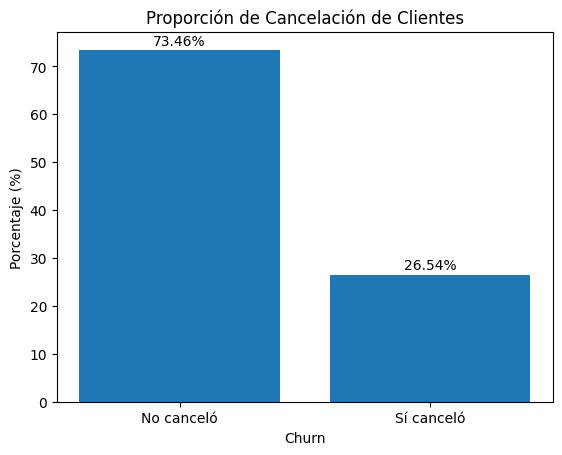

In [34]:
import matplotlib.pyplot as plt

# Calcular proporciones en porcentaje
proporciones = (datos['Churn'].value_counts(normalize=True) * 100).round(2)

# Crear gráfica
plt.figure()
plt.bar(proporciones.index.astype(str), proporciones.values)

# Etiquetas
plt.xlabel("Churn")
plt.ylabel("Porcentaje (%)")
plt.title("Proporción de Cancelación de Clientes")
plt.xticks([0, 1], ['No canceló', 'Sí canceló'])

# Mostrar valores encima de las barras
for i, v in enumerate(proporciones.values):
    plt.text(i, v + 1, str(v) + "%", ha='center')

plt.show()



### <font color='purple'>En conlución

*La variable objetivo presenta un desbalance moderado, con 73.4% de clientes activos y 26.53% de clientes que cancelaron. Este desbalance puede afectar el desempeño de los modelos predictivos, por lo que no se debe utilizar únicamente la métrica de accuracy para evaluar el modelo. Por lo que usaremos las isguientes métricas: recall, precision y F1-score.*

##**4.6 Verificación de Transformaciones**

Para verificar que las variables fueron corretamente tranformadas

In [36]:
X_train_transformado = preprocesador.fit_transform(X_train)

feature_names = preprocesador.get_feature_names_out()

X_train_df = pd.DataFrame(X_train_transformado, columns=feature_names)

X_train_df.head()

,num__Tenure,num__ChargesMonthly,cat__Gender_Male,cat__SeniorCitizen_Yes,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_Yes,cat__InternetService_DSL,cat__InternetService_Fiber optic,...,cat__StreamingTV_Yes,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,0.194444,0.578475,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.069444,0.514200,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.486111,0.566019,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.805556,0.674639,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,0.027778,0.310912,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


*Verificar normalización de numericas*

In [37]:
X_train_df.filter(like='num__').describe()

,num__Tenure,num__ChargesMonthly
count,4930.000000,4930.000000
mean,0.451755,0.465478
std,0.341598,0.300319
min,0.000000,0.000000
25%,0.125000,0.178376
50%,0.402778,0.519930
75%,0.777778,0.714001
max,1.000000,1.000000


In [38]:
X_train_df.filter(like='cat__').head()

,cat__Gender_Male,cat__SeniorCitizen_Yes,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_Yes,cat__InternetService_DSL,cat__InternetService_Fiber optic,cat__InternetService_No,cat__OnlineSecurity_Yes,...,cat__StreamingTV_Yes,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


# <font color='blue'>***5 Modelado Predictivo***

##**5.1 Creación de modelos**

<font color='green'>***Modelo 1: Logistic Regression***

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline_log = Pipeline(steps=[
    ('preprocessing', preprocesador),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline_log.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  Index(['Tenure', 'ChargesMonthly'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

<font color='green'>***Modelo 2: Random Forest***

In [40]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline(steps=[
    ('preprocessing', preprocesador),
    ('model', RandomForestClassifier(
        n_estimators=200,

        random_state=42
    ))
])

pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  Index(['Tenure', 'ChargesMonthly'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

## **5.2 Evaluación de los modelos**

Primero hacemos la predición para ambos

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# Logistic
y_pred_log = pipeline_log.predict(X_test)
y_proba_log = pipeline_log.predict_proba(X_test)[:,1]

# Random Forest
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:,1]

**📊 Métricas – Logistic Regression**

In [42]:
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_log))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

=== Logistic Regression ===
Accuracy: 0.7974443918599148

Matriz de Confusión:
[[1381  171]
 [ 257  304]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1552
           1       0.64      0.54      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113

ROC-AUC: 0.8387722356984031


**📊 Métricas – Random Forest**

In [43]:
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

=== Random Forest ===
Accuracy: 0.7870326549929011

Matriz de Confusión:
[[1375  177]
 [ 273  288]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.62      0.51      0.56       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113

ROC-AUC: 0.8159059898561112


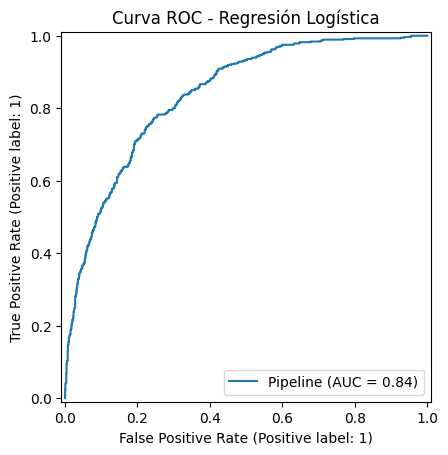

In [47]:
from sklearn.metrics import RocCurveDisplay
import os

# Create the directory if it doesn't exist
output_dir = "visualizaciones"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

RocCurveDisplay.from_estimator(pipeline_log, X_test, y_test)
plt.title("Curva ROC - Regresión Logística")
plt.savefig(os.path.join(output_dir, "roc_curve.png"), dpi=300, bbox_inches='tight')
plt.show()

**¿Hay overfitting?**

In [49]:
print("Logistic Train Accuracy:", pipeline_log.score(X_train, y_train))
print("Logistic Test Accuracy:", pipeline_log.score(X_test, y_test))

print("RF Train Accuracy:", pipeline_rf.score(X_train, y_train))
print("RF Test Accuracy:", pipeline_rf.score(X_test, y_test))

Logistic Train Accuracy: 0.8089249492900609
Logistic Test Accuracy: 0.7974443918599148
RF Train Accuracy: 0.9975659229208925
RF Test Accuracy: 0.7870326549929011


📊 1️⃣ Comparación General de Desempeño

| Métrica             | Logistic  | Random Forest |
| ------------------- | --------- | ------------- |
| Accuracy            | **0.797** | 0.787         |
| Recall (Churn=1)    | **0.54**  | 0.51          |
| Precision (Churn=1) | **0.64**  | 0.62          |
| F1-score (Churn=1)  | **0.59**  | 0.56          |
| ROC-AUC             | **0.839** | 0.816         |


🧠 2️⃣ Interpretación Estratégica

**🔹 Accuracy**

* Ambos modelos rondan el 79–80%.

* El dataset tiene 73% de clase mayoritaria.

* Un modelo trivial tendría ~73% de accuracy.

👉 Entonces sí están aprendiendo información útil.

__


**🔹 Recall Clase 1 (lo más importante)**

* Logistic: 0.54
* Random Forest: 0.51

Esto significa:

* Logistic detecta 54% de los clientes que cancelan.

* Random Forest detecta 51%.

📌 Ninguno es extraordinario, pero Logistic es ligeramente mejor.

En churn, el recall de la clase positiva es clave.

__

**🔹 ROC-AUC**

* Logistic: 0.84
* Random Forest: 0.82

Ambos son buenos (>0.80 es buen modelo). Sin embargo Logistic mostro mejores resultados

**🚨 3️⃣ Overfitting / Underfitting**

***Logistic Regression***

* Train: 0.809
* Test: 0.797

Diferencia pequeña (~1%)

👉 Hubó generalización

👉 No hay overfitting

👉 El modelo mostro ser estable

***Random Forest***

* Train: 0.997
* Test: 0.787

🚨 Diferencia enorme (~21%)

* Mostro overfitting .

* Con base al resultado el modelo prácticamente memoriza el entrenamiento.

* El resultado puede dewberse a la limitación de la profundidad

**🎯 4️⃣ ¿Cuál modelo tuvo mejor desempeño?**

La Regresión Logística mostró mejor desempeño general, mayor capacidad discriminativa (ROC-AUC) y mejor balance entre precisión y recall. Además, presentó una adecuada capacidad de generalización sin evidencia significativa de sobreajuste, a diferencia del modelo Random Forest, que mostró un marcado overfitting.

**📌 5️⃣ ¿Hay underfitting?**

* No.

* Ambos modelos tienen desempeño razonable (>0.78 accuracy y >0.80 ROC-AUC).

**🧩 6️⃣ Mejora Futuras**

El recall de 0.54 aún significa:

👉 Estamos perdiendo 46% de los clientes que cancelan.

Podríamos mejorar:

* Ajustando class_weight='balanced' en Logistic

* Moviendo el threshold (no usar 0.5)

* Ajustando hiperparámetros

* Pero como modelo base, está bien.

<font color='red'>***Aunque el modelo Random Forest mostró alta exactitud en entrenamiento (99.7%), su desempeño disminuyó considerablemente en el conjunto de prueba, evidenciando sobreajuste. Por otro lado, la Regresión Logística presentó una diferencia mínima entre entrenamiento y prueba, indicando buena capacidad de generalización. Además, obtuvo mejor desempeño en ROC-AUC y recall para la clase de interés (clientes que cancelan), por lo que se considera el modelo más adecuado en esta etapa inicial.***

# <font color='blue'>***6 Interpretación y Conclusiones***

## **6.1 Analisis de la importancia de las varibles**

**🔎 7️⃣ Interpretación de Variables – Logistic Regression**

✅ Obtener nombres de *variables*

In [50]:
feature_names = pipeline_log.named_steps['preprocessing'].get_feature_names_out()

✅ Obtener coeficientes

In [51]:
coeficientes = pipeline_log.named_steps['model'].coef_[0]

✅ Crear DataFrame ordenado

In [52]:
import pandas as pd

importancias = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coeficientes
})

importancias = importancias.sort_values(by='Coeficiente', ascending=False)

importancias.head(10)

,Variable,Coeficiente
9,cat__InternetService_Fiber optic,0.659272
17,cat__Contract_Month-to-month,0.561165
20,cat__PaperlessBilling_Yes,0.404922
7,cat__MultipleLines_Yes,0.280160
15,cat__StreamingTV_Yes,0.243505
1,num__ChargesMonthly,0.230291
16,cat__StreamingMovies_Yes,0.199321
23,cat__PaymentMethod_Electronic check,0.191797
3,cat__SeniorCitizen_Yes,0.172695
13,cat__DeviceProtection_Yes,0.012984


In [53]:
importancias['Abs'] = importancias['Coeficiente'].abs()
importancias.sort_values(by='Abs', ascending=False).head(15)

,Variable,Coeficiente,Abs
0,num__Tenure,-2.420735,2.420735
10,cat__InternetService_No,-0.884975,0.884975
19,cat__Contract_Two year,-0.742901,0.742901
9,cat__InternetService_Fiber optic,0.659272,0.659272
17,cat__Contract_Month-to-month,0.561165,0.561165
6,cat__PhoneService_Yes,-0.514342,0.514342
20,cat__PaperlessBilling_Yes,0.404922,0.404922
14,cat__TechSupport_Yes,-0.393020,0.393020
11,cat__OnlineSecurity_Yes,-0.284382,0.284382
7,cat__MultipleLines_Yes,0.280160,0.280160


**🔺 1️⃣ Variables que MÁS Aumentan la Probabilidad de Cancelación**

Tus coeficientes positivos más fuertes:

| Variable                       | Coef      |
| ------------------------------ | --------- |
| InternetService_Fiber optic    | **0.659** |
| Contract_Month-to-month        | **0.561** |
| PaperlessBilling_Yes           | 0.405     |
| MultipleLines_Yes              | 0.280     |
| StreamingTV_Yes                | 0.244     |
| MonthlyCharges                 | 0.230     |
| StreamingMovies_Yes            | 0.199     |
| PaymentMethod_Electronic check | 0.192     |
| SeniorCitizen_Yes              | 0.173     |


**🔎 Interpretación**

**🔥 Fiber optic (+0.659)**

Los clientes con fibra óptica tienen mayor probabilidad de cancelar.

Debido a:

* Es servicio más costoso.

* Expectativa más alta → mayor insatisfacción si falla.

**🔥 Contrato mensual (+0.561)**

Clientes con contrato mes a mes son mucho más propensos a cancelar.

👉 No tienen compromiso.

👉 Mayor flexibilidad para irse.

***Con base a este analisi, se podria partir de este puento para futuras mejoras al servicio***

**🔥 Cargos mensuales altos (+0.230)**

* A mayor MonthlyCharges → mayor churn.

* Esto confirma sensibilidad al precio.

**🔥 Pago con Electronic Check (+0.192)**

Este método suele asociarse con clientes menos automatizados.
Podría correlacionar con menor fidelidad.

🔻 2️⃣ Variables que MÁS Reducen la Probabilidad de Cancelación

| Variable                | Coef      |
| ----------------------- | --------- |
| Tenure                  | **-2.42** |
| InternetService_No      | -0.885    |
| Contract_Two year       | -0.743    |
| PhoneService_Yes        | -0.514    |
| TechSupport_Yes         | -0.393    |
| OnlineSecurity_Yes      | -0.284    |
| Credit card (automatic) | -0.256    |
| Dependents_Yes          | -0.207    |


**🔎 Interpretación**

**🔥 Tenure (-2.42)**

* Es la variable más importante de todo el modelo.

* A mayor antigüedad → muchísimo menor probabilidad de cancelación.

Conclusión:

👉 La retención temprana es crítica.

👉 Si un cliente sobrevive los primeros meses, es muy probable que permanezca.


**🔥 Contrato de dos años (-0.743)**

* Compromiso largo reduce churn significativamente.

* Una estrategia partiendo de este punto: Inventiva a contratos largos.

**🔥 Tener TechSupport (-0.393)**

* Clientes con soporte técnico cancelan menos.

* Posible explicación:

* Se sienten respaldados.

* Resuelven problemas antes de frustrarse.

**🔥 Seguridad en línea (-0.284)**

* Servicios adicionales aumentan fidelidad.

**🧠 Insight profundo**

Observamos  algo interesante:

Variables asociadas a "servicios adicionales" tienen efectos mixtos:

* Algunos aumentan churn (StreamingTV)

* Otros lo reducen (TechSupport)

Esto sugiere que:
No es tener más servicios, sino tener servicios que generen valor real.

## <font color='#FF5733'>***6.2 Conclusion***

El análisis de coeficientes de la Regresión Logística revela que la antigüedad del cliente (tenure) es el factor más determinante en la reducción de la cancelación. Asimismo, los contratos de largo plazo disminuyen significativamente la probabilidad de churn, mientras que los contratos mensuales la incrementan considerablemente.

Los cargos mensuales elevados y el uso de fibra óptica se asocian con mayor probabilidad de cancelación, lo que sugiere sensibilidad al precio y posibles expectativas no satisfechas del servicio.

La inclusión de servicios como soporte técnico y seguridad en línea reduce la probabilidad de cancelación, indicando que el valor percibido y la asistencia al cliente son elementos clave en la retención.